In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [6]:
df = pd.read_csv('SaaS-Sales.csv')

In [7]:
df.head(10)

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164
5,6,AMER-2020-115812,6/9/2020,20200609,Thomas Hodges,United States,New York City,AMER,NAMER,BNP Paribas,1065,Finance,SMB,SaaS Connector Pack,8RM88WFOAE,48.8600,7,0.00,14.1694
6,7,AMER-2020-115812,6/9/2020,20200609,Thomas Hodges,United States,New York City,AMER,NAMER,BNP Paribas,1065,Finance,SMB,ChatBot Plugin,4SYTVM0746,7.2800,4,0.00,1.9656
7,8,AMER-2020-115812,6/9/2020,20200609,Thomas Hodges,United States,New York City,AMER,NAMER,BNP Paribas,1065,Finance,SMB,Site Analytics,07842ES7DY,907.1520,6,0.20,90.7152
8,9,AMER-2020-115812,6/9/2020,20200609,Thomas Hodges,United States,New York City,AMER,NAMER,BNP Paribas,1065,Finance,SMB,ContactMatcher,XPBOBXWXA3,18.5040,3,0.20,5.7825
9,10,AMER-2020-115812,6/9/2020,20200609,Thomas Hodges,United States,New York City,AMER,NAMER,BNP Paribas,1065,Finance,SMB,OneView,71J8P9Z1P0,114.9000,5,0.00,34.4700


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   object 
 2   Order Date    9994 non-null   object 
 3   Date Key      9994 non-null   int64  
 4   Contact Name  9994 non-null   object 
 5   Country       9994 non-null   object 
 6   City          9994 non-null   object 
 7   Region        9994 non-null   object 
 8   Subregion     9994 non-null   object 
 9   Customer      9994 non-null   object 
 10  Customer ID   9994 non-null   int64  
 11  Industry      9994 non-null   object 
 12  Segment       9994 non-null   object 
 13  Product       9994 non-null   object 
 14  License       9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Profit        9994 non-null 

# **Data Cleaning**

### Memeriksa Missing Value

In [9]:
df.isnull().sum()

Row ID          0
Order ID        0
Order Date      0
Date Key        0
Contact Name    0
Country         0
City            0
Region          0
Subregion       0
Customer        0
Customer ID     0
Industry        0
Segment         0
Product         0
License         0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

### Memeriksa data duplikat

In [10]:
df['Row ID'].duplicated().sum()

np.int64(0)

### Mengubah tipe data order date menjadi datetime

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Row ID        9994 non-null   int64         
 1   Order ID      9994 non-null   object        
 2   Order Date    9994 non-null   datetime64[ns]
 3   Date Key      9994 non-null   int64         
 4   Contact Name  9994 non-null   object        
 5   Country       9994 non-null   object        
 6   City          9994 non-null   object        
 7   Region        9994 non-null   object        
 8   Subregion     9994 non-null   object        
 9   Customer      9994 non-null   object        
 10  Customer ID   9994 non-null   int64         
 11  Industry      9994 non-null   object        
 12  Segment       9994 non-null   object        
 13  Product       9994 non-null   object        
 14  License       9994 non-null   object        
 15  Sales         9994 non-null   float64 

# **Exploratory Data Analysis**

In [12]:
df_product = df.groupby('Product')[['Sales','Profit','Quantity']].sum().reset_index()
df_product['Profit Margin Percentage'] = round((df_product['Profit']/df_product['Sales'])*100,2)
df_product = df_product.sort_values('Profit',ascending=False)
df_product

,Product,Sales,Profit,Quantity,Profit Margin Percentage
0,Alchemy,149528.0300,55617.8249,234,37.20
11,Site Analytics,330007.0540,44515.7306,3289,13.49
4,Data Smasher,167380.3180,41936.6357,2976,25.05
13,Support,125152.7440,32864.4698,5825,26.26
5,FinanceHub,340935.4150,32136.4203,3756,9.43
7,Marketing Suite - Gold,223843.6080,21278.8264,3158,9.51
8,OneView,107532.1610,18138.0054,1729,16.87
9,SaaS Connector Pack,91705.1640,13059.1436,3563,14.24
3,ContactMatcher,410378.2650,12496.2822,7215,3.05
10,SaaS Connector Pack - Gold,16476.4020,6964.1767,906,42.27


C:\Users\dwisanjani\AppData\Local\Temp\ipykernel_34768\4199946712.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(df_product.sort_values('Profit',ascending=False),y='Product',x='Profit',palette='Purples')


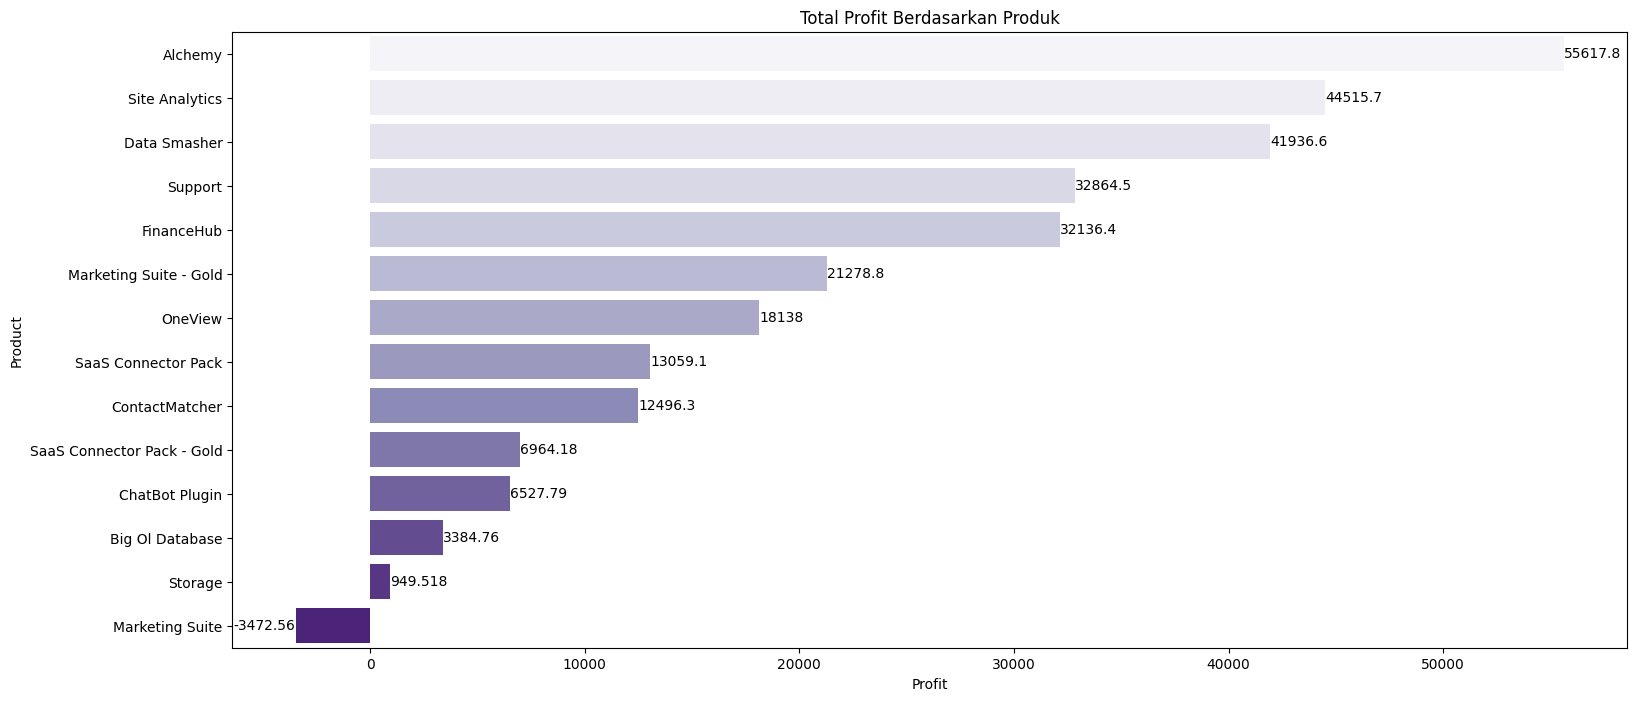

In [54]:
fig = plt.figure(figsize=(18,8))
ax = sns.barplot(df_product.sort_values('Profit',ascending=False),y='Product',x='Profit',palette='Purples')
plt.title("Total Profit Berdasarkan Produk")

for value in ax.containers:
    ax.bar_label(value)

plt.show()

## Problem Statement
#### Marketing Suite adalah produk AWS yang menjadi sumber kerugian perusahaan pada periode 2020 - 2023

### 1. Tren Penjualan dan Keuntungan Marketing Suite

In [14]:
df['Order Month'] = df['Order Date'].dt.to_period("M")
df['Order Month'] = df['Order Month'].astype('str')

In [15]:
df_ms = df[df['Product']=='Marketing Suite']
df_lineplot = df_ms.groupby('Order Month')[['Sales','Profit']].sum().reset_index()
df_lineplot['Profit Margin Percentage'] = round((df_lineplot['Profit']/df_lineplot['Sales'])*100,2)

In [16]:
df_lineplot_year = df_lineplot.copy()
df_lineplot_year['Year'] = df_lineplot['Order Month'].str[:4]
df_lineplot_year = df_lineplot_year[['Year','Sales','Profit']]
df_lineplot_year = df_lineplot_year.groupby('Year')[['Sales','Profit']].sum().reset_index()
df_lineplot_year['Profit Margin Percentage'] = round((df_lineplot_year['Profit']/df_lineplot_year['Sales'])*100,2)

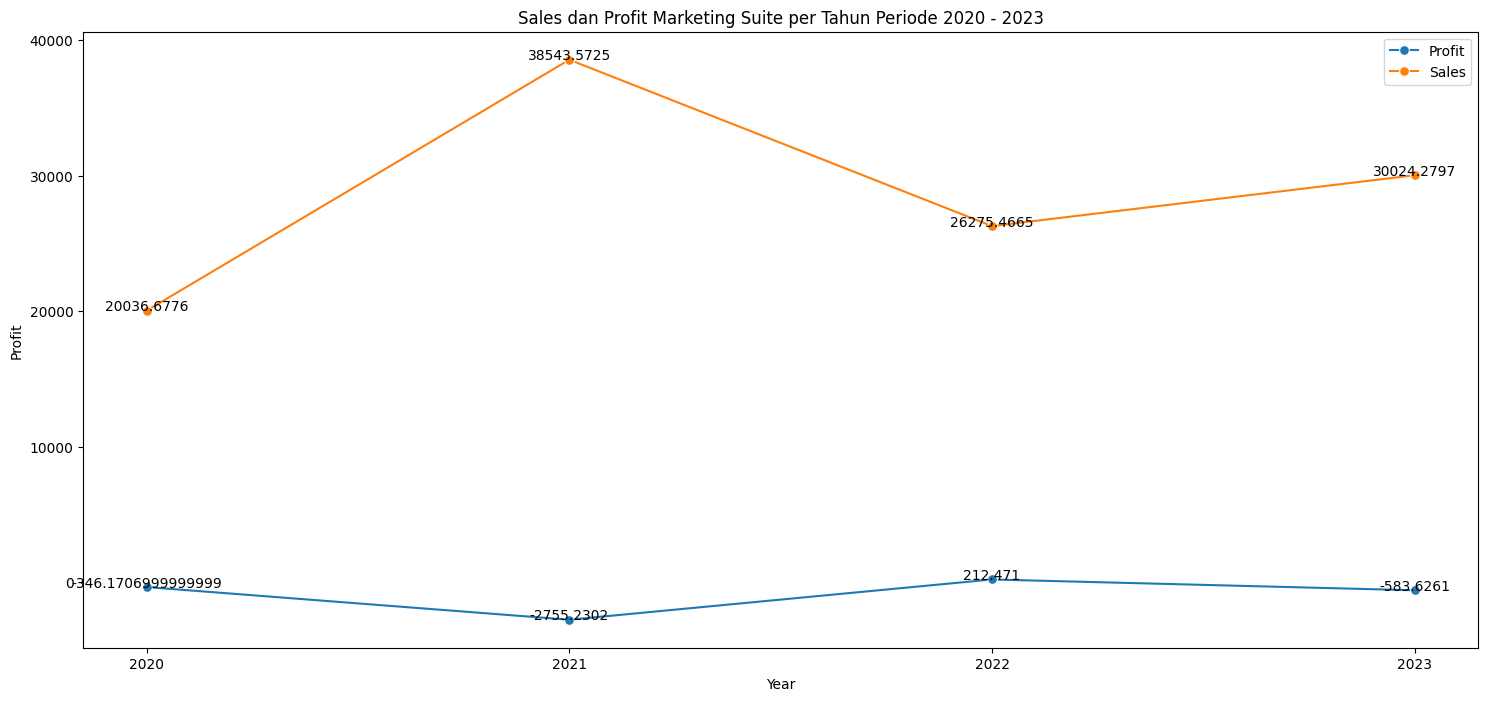

In [17]:
fig = plt.figure(figsize=(18,8))

ax1 = sns.lineplot(data=df_lineplot_year,x='Year',y='Profit',markers=True,marker='o',markersize=7,label='Profit')
ax2 = sns.lineplot(data=df_lineplot_year,x='Year',y='Sales',markers=True,marker='o',markersize=7,label='Sales')

for x, y in zip(df_lineplot_year['Year'], df_lineplot_year['Sales']):
    plt.text(x, y + 2, f'{y}', color='black', ha='center')

for x, y in zip(df_lineplot_year['Year'], df_lineplot_year['Profit']):
    plt.text(x, y + 2, f'{y}', color='black', ha='center')

plt.title("Sales dan Profit Marketing Suite per Tahun Periode 2020 - 2023")
plt.legend()
plt.show()

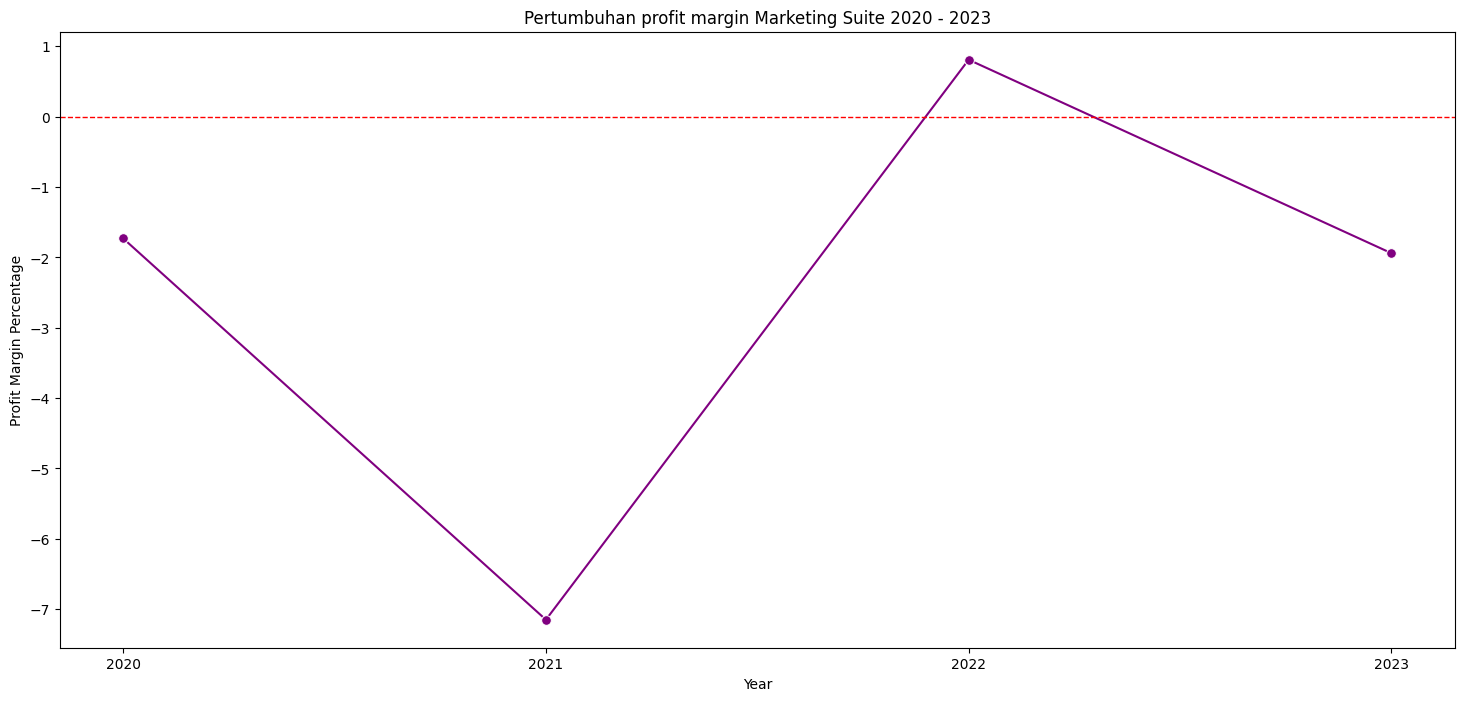

In [57]:
fig = plt.figure(figsize=(18,8))
ax = sns.lineplot(data=df_lineplot_year,x='Year',y='Profit Margin Percentage',markers=True,marker='o',markersize=7,color='purple')
ax.axhline(color='red',linestyle='--',linewidth=1)
plt.title("Pertumbuhan profit margin Marketing Suite 2020 - 2023")
plt.show()

In [19]:
df_lineplot_year.sort_values(by='Profit')

,Year,Sales,Profit,Profit Margin Percentage
1,2021,38543.5725,-2755.2302,-7.15
3,2023,30024.2797,-583.6261,-1.94
0,2020,20036.6776,-346.1707,-1.73
2,2022,26275.4665,212.4710,0.81


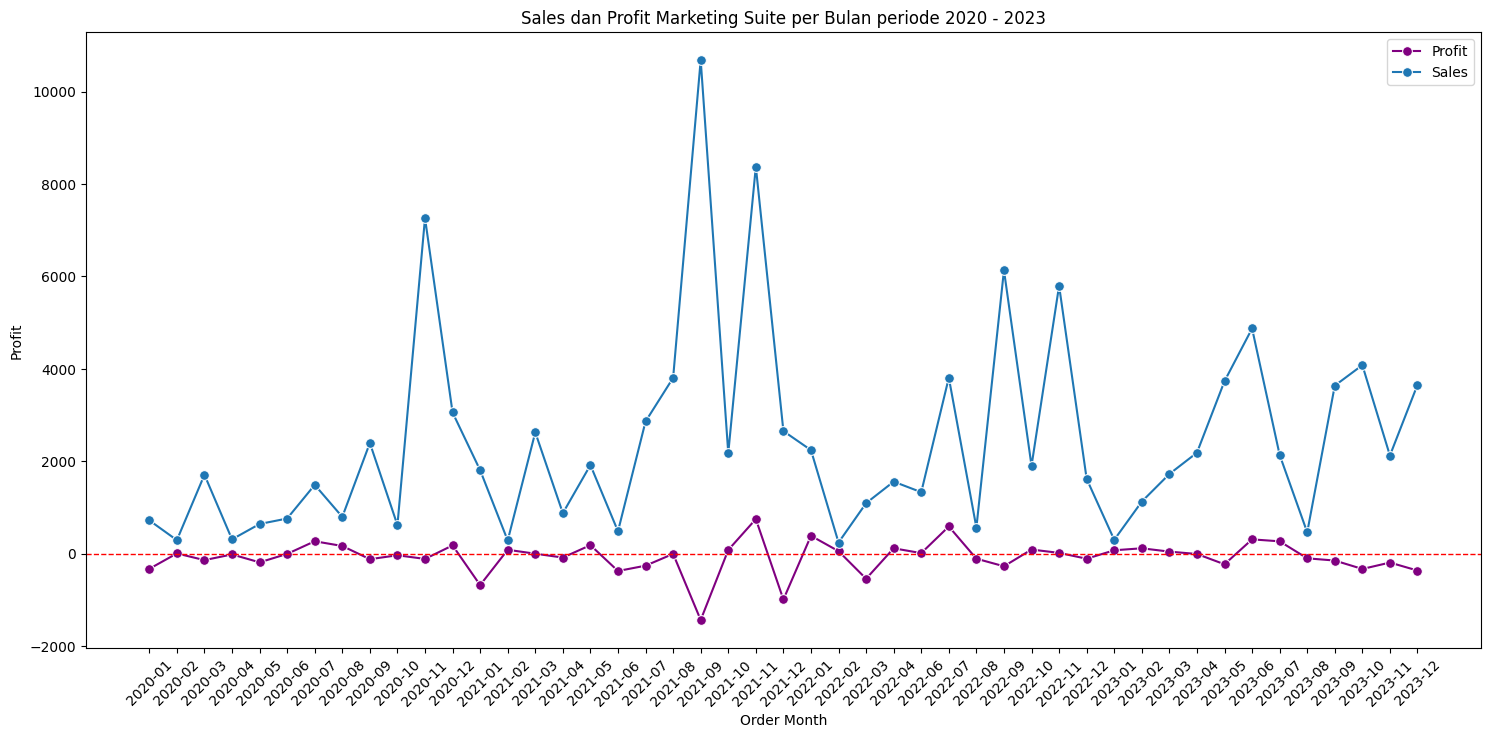

In [55]:
fig = plt.figure(figsize=(18,8))
ax = sns.lineplot(data=df_lineplot,x='Order Month',y='Profit',markers=True,marker='o',markersize=7,label='Profit',color='purple')
sns.lineplot(data=df_lineplot,x='Order Month',y='Sales',markers=True,marker='o',markersize=7,label='Sales')
ax.axhline(color='red',linestyle='--',linewidth=1)
plt.title("Sales dan Profit Marketing Suite per Bulan periode 2020 - 2023")
plt.xticks(rotation=45)
plt.legend()
plt.show()

<Axes: ylabel='Profit'>

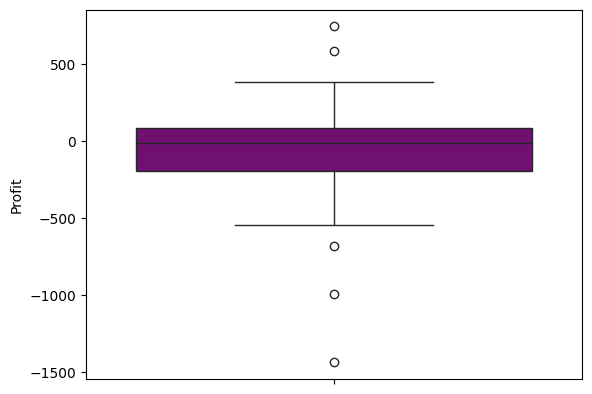

In [56]:
sns.boxplot(df_lineplot['Profit'],color='purple')

#### Penemuan
* Pertumbuhan sales dan profit Marketing Suite setiap tahun selama 2020 - 2023 berjalan secara tidak konsisten
* Total kerugian terbesar yang dihasilkan dari penjualan Marketing Suite terjadi pada tahun 2021, yaitu sebesar 2755.23 USD
* Profit Marketing Suite per bulan selama 2020 - 2023 terlihat stagnan dan cenderung negatif 

#### Analisa
* Walaupun terjadi kenaikan sales dan profit kuantitas di beberapa, laba yang didapatkan tetap bernilai negatif, keuntungan yang ada tidak dapat menutup kerugian
* Walaupun memiliki penjualan, rata-rata keuntungan marketing suite perbulan berada di dekat nilai 0, ada kesalahan dari segi pricing dan marketing

### 2. Marketing Suite di semua region

In [22]:
df_region = df_ms.groupby('Region')[['Sales','Profit','Quantity','Discount']].sum().reset_index().sort_values(by='Sales',ascending=False)
df_region['Profit Margin Percentage'] = round((df_region['Profit']/df_region['Sales'])*100,2)
df_region

,Region,Sales,Profit,Quantity,Discount,Profit Margin Percentage
2,EMEA,54568.6300,-1629.6682,390,22.60,-2.99
0,AMER,36385.9795,52.7756,292,13.90,0.15
1,APJ,23925.3868,-1895.6634,186,11.64,-7.92


In [ ]:
#Customer yang menggunakan diskon
df_discount_user = df_ms[df_ms['Discount']>0]
df_discount_user.groupby('Region')[['Customer']].nunique().reset_index()


,Region,Customer
0,AMER,47
1,APJ,26
2,EMEA,48


In [ ]:
#Semua Customer berdasarkan region
df_ms.groupby('Region')[['Customer']].nunique().reset_index()

,Region,Customer
0,AMER,54
1,APJ,35
2,EMEA,63


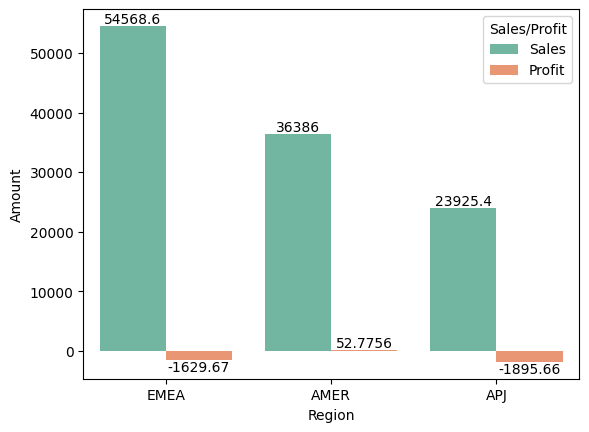

In [58]:
df_grouped_bar = df_region[['Region','Sales','Profit']].melt('Region',var_name='Sales/Profit',value_name='Amount')
df_grouped_bar = df_grouped_bar[['Region','Sales/Profit','Amount']]

ax = sns.barplot(data=df_grouped_bar,x='Region',y='Amount',hue='Sales/Profit',palette='Set2')

for value in ax.containers:
    ax.bar_label(value)

In [104]:
df_ms_apjemea = df_ms[(df_ms['Region']=='APJ')|(df_ms['Region']=='EMEA')]

Text(0.5, 1.0, 'Korelasi Penjualan Marketing Suite APJ dan EMEA')

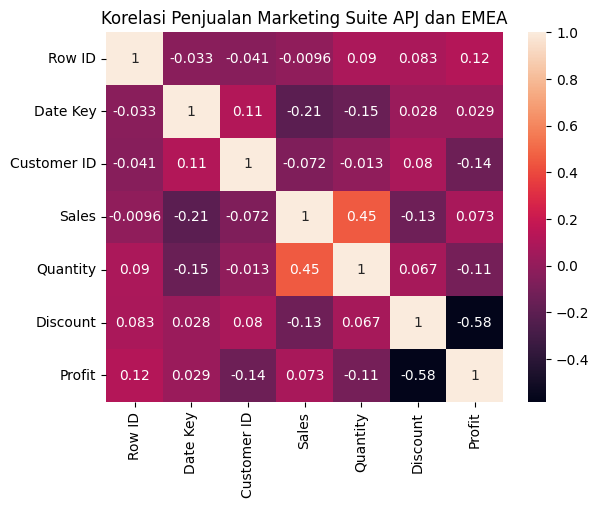

In [107]:
corr_apjemea = df_ms_apjemea.corr(numeric_only=True)
sns.heatmap(corr_apjemea,annot=True)
plt.title("Korelasi Penjualan Marketing Suite APJ dan EMEA")

In [24]:
df_subregion = df_ms.groupby(['Region','Subregion'])[['Sales','Profit','Discount','Quantity']].sum().reset_index()
df_subregion['Profit Margin Percentage'] = round((df_subregion['Profit']/df_subregion['Sales'])*100,2)
df_subregion.sort_values('Region')

,Region,Subregion,Sales,Profit,Discount,Quantity,Profit Margin Percentage
0,AMER,LATAM,5682.9980,-1936.2213,6.10,66,-34.07
1,AMER,NAMER,30702.9815,1988.9969,7.80,226,6.48
2,APJ,ANZ,4282.6980,-555.8726,3.00,43,-12.98
3,APJ,APAC,5149.2300,1051.3469,0.00,38,20.42
4,APJ,JAPN,14493.4588,-2391.1377,8.64,105,-16.50
5,EMEA,EU,3873.9600,650.7630,0.00,27,16.80
6,EMEA,EU-EAST,2618.0830,-2184.3301,6.30,53,-83.43
7,EMEA,EU-WEST,9777.4870,-3257.8735,8.70,104,-33.32
8,EMEA,MEA,9944.5000,1854.2242,0.40,43,18.65
9,EMEA,NOR,5315.4960,914.7602,0.80,48,17.21


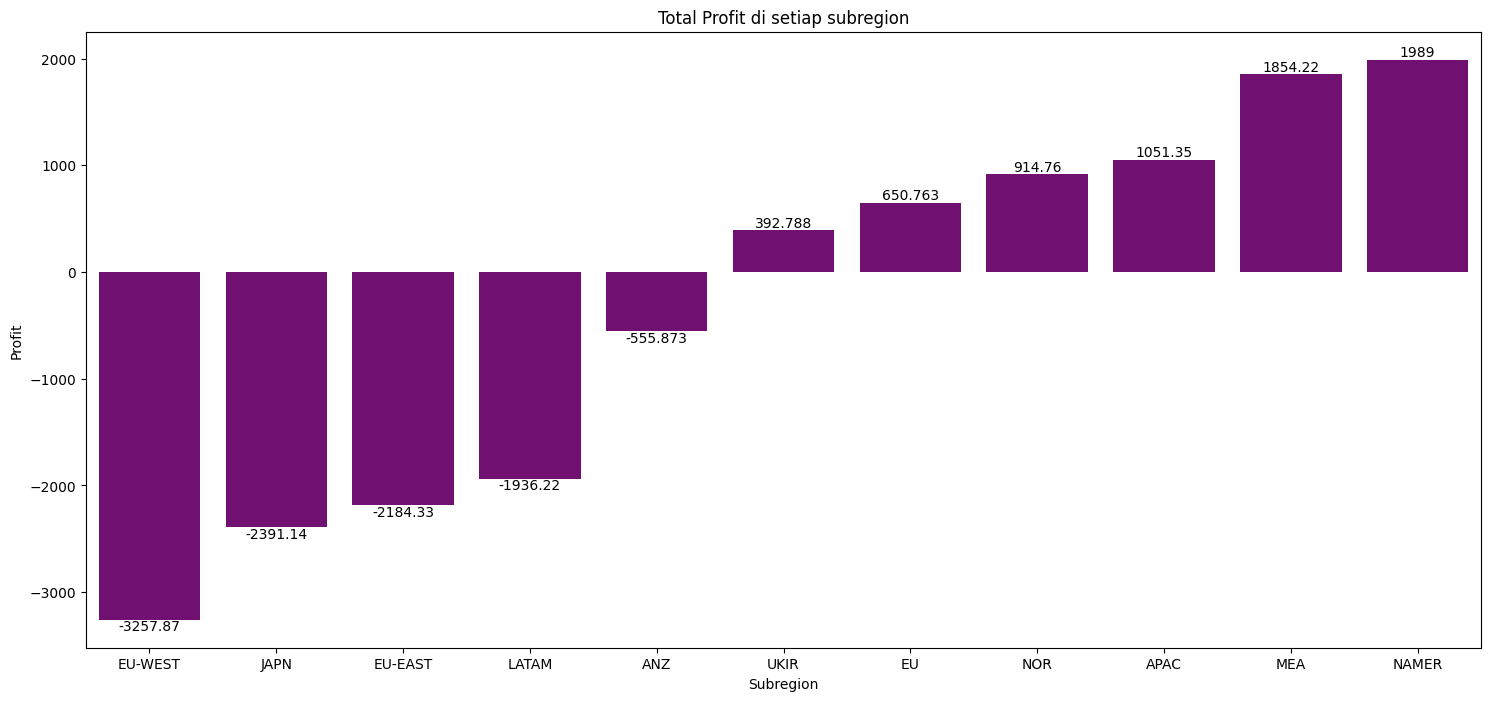

In [73]:
fig = plt.figure(figsize=(18,8))
ax = sns.barplot(data=df_subregion.sort_values('Profit'),x='Subregion',y='Profit',color='purple')
plt.title("Total Profit di setiap subregion")
for value in ax.containers:
    ax.bar_label(value)

#### Penemuan
* EMEA ada region dengan sales marketing suite tertinggi, namun menghasilkan laba negatif
* AMER menjadi satu-satunya region dimana penjualan marketing suite mendatangkan laba positif
* APJ menjadi region dengan performa terburuk dari semua segi
* Sales sebesar 23925, kerugian sebesar 1895.66 dan produk hanya terjual 186 unit di region APJ

#### Analisa
* Pihak marketing gagal dalam melakukan marketing mix produk marketing suite di semua region
* EMEA memiliki sales yang lebih tinggi dari AMER namun, profit jauh dibawah dari AMER
* margin yang diambil AMER hanya sebesar 0.15%, terlalu kecil untuk dapat dikatakan bisnis di region tersebut berhasil
* margin laba AMER yang sangat kecil disebabkan oleh margin laba subregion LATAM sebesar -34,07%, perlu dilakukan audit pada subregion tersebut
* Dibutuhkan audit dari semua faktor yang berhubungan dengan penjualan marketing suite di region APJ, terutama pada subregion JPN
* Dibutuhkan audit dari semua faktor yang berhubungan dengan penjualan marketing suite di region EMEA, terutama pada subregion EU-EAST dan EU-WEST


### 3. Segmentasi Konsumen Marketing Suite

In [87]:
df_cust = df_ms.groupby('Customer').agg({
    'Industry':lambda x: x.mode().iat[0] if not x.mode().empty else None,
    'Segment':lambda x: x.mode().iat[0] if not x.mode().empty else None,
    'Sales':'sum',
    'Profit':'sum',
    'Quantity':'sum',
    'Discount':'sum',}).reset_index()
df_cust['Profit Margin Percentage'] = round((df_cust['Profit']/df_cust['Sales'])*100,)
df_cust = df_cust.sort_values(by='Profit')
df_cust.head(10)

,Customer,Industry,Segment,Sales,Profit,Quantity,Discount,Profit Margin Percentage
44,Intel,Tech,SMB,4856.0630,-1561.8110,21,1.05,-32.0
58,Nissan Motor,Transportation,SMB,2242.4306,-1392.2704,21,1.52,-62.0
12,Banco Santander,Finance,Strategic,1213.6112,-455.8888,17,1.02,-38.0
11,BNP Paribas,Finance,Strategic,3095.4188,-390.0588,30,1.54,-13.0
22,Cisco Systems,Tech,SMB,217.7640,-384.7164,6,0.70,-177.0
16,Bosch,Tech,Strategic,242.3520,-363.5280,8,0.70,-150.0
64,Phillips 66,Energy,Strategic,1514.3770,-345.1403,18,0.85,-23.0
51,McKesson,Consumer Products,SMB,1233.8850,-327.4683,12,0.70,-27.0
71,Sony,Tech,Enterprise,2644.2368,-323.6812,21,1.37,-12.0
38,HSBC Holdings,Finance,SMB,578.1885,-313.8780,14,1.35,-54.0


C:\Users\dwisanjani\AppData\Local\Temp\ipykernel_34768\645519189.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cust_loss['Profit'] = df_cust_loss['Profit']*-1


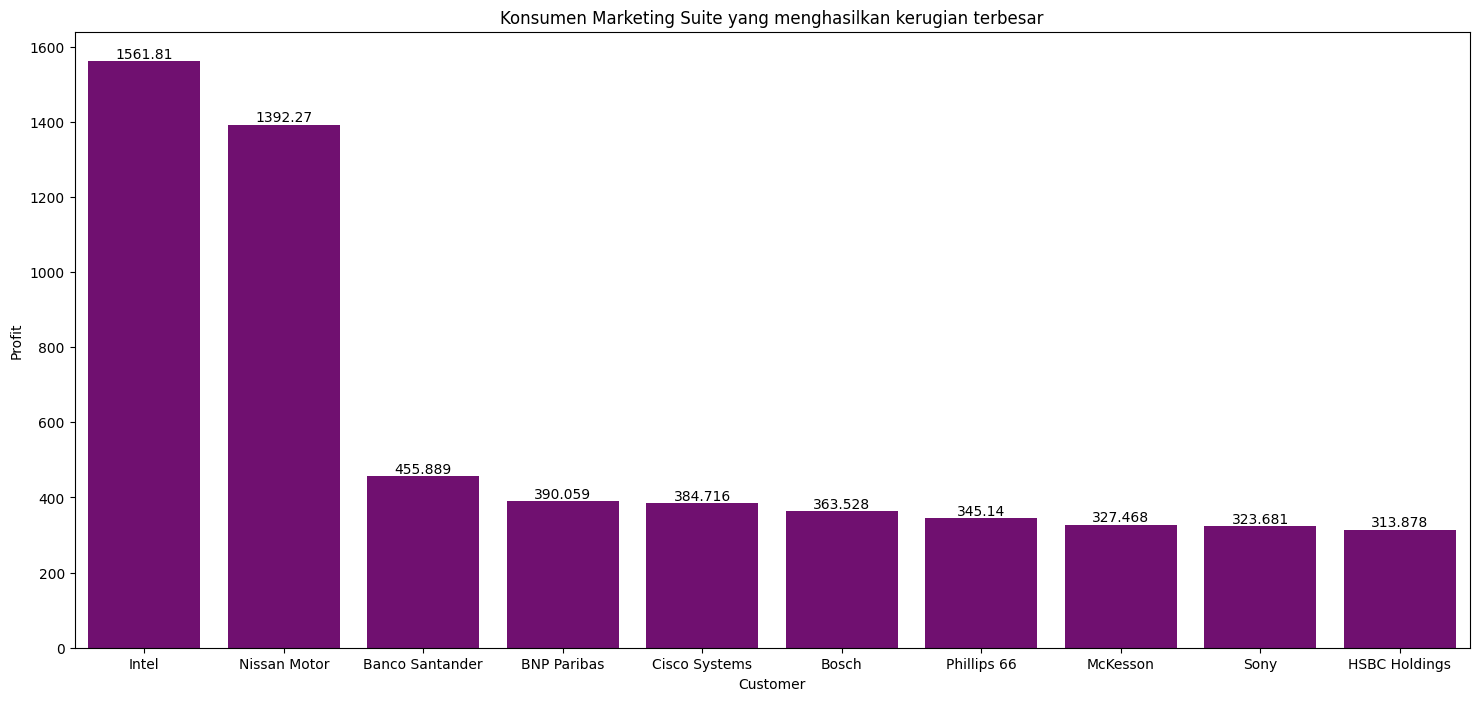

In [84]:
df_cust_loss = df_cust.head(10)
df_cust_loss['Profit'] = df_cust_loss['Profit']*-1

fig = plt.figure(figsize=(18,8))
ax = sns.barplot(data=df_cust_loss,x='Customer',y='Profit',color='purple')
plt.title("Konsumen Marketing Suite yang menghasilkan kerugian terbesar")

for value in ax.containers:
    ax.bar_label(value)

In [26]:
df_cust.sort_values(by='Profit',ascending=False).head(10)

,Customer,Industry,Segment,Sales,Profit,Quantity,Discount,Profit Margin Percentage
69,Samsung Electronics,Tech,Strategic,4404.900,1013.1270,5,0.00,23.0
31,Exxon Mobil,Energy,Strategic,2122.545,413.6778,11,0.15,19.0
8,Apple,Tech,SMB,2302.230,323.0052,15,0.50,14.0
76,Tesco,Retail,SMB,1266.860,291.3778,7,0.00,23.0
67,Royal Dutch Shell,Energy,SMB,1167.840,277.1208,8,0.00,24.0
4,Amazon,Tech,SMB,3398.080,266.6074,24,0.45,8.0
50,Marathon Petroleum,Energy,Enterprise,1716.711,241.9246,9,0.15,14.0
80,United Parcel Service,Transportation,SMB,1568.733,236.5938,7,0.35,15.0
53,Mitsubishi,Manufacturing,Enterprise,1988.267,215.8104,13,0.55,11.0
6,AmerisourceBergen,Healthcare,SMB,716.548,181.3714,11,0.20,25.0


C:\Users\dwisanjani\AppData\Local\Temp\ipykernel_34768\597772096.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cust.sort_values(by='Sales',ascending=False).head(10),y='Customer',x='Sales',palette='Greens',ax=ax1)
C:\Users\dwisanjani\AppData\Local\Temp\ipykernel_34768\597772096.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cust.sort_values(by='Profit',ascending=False).head(10),y='Customer',x='Profit',palette='Blues',ax=ax2)


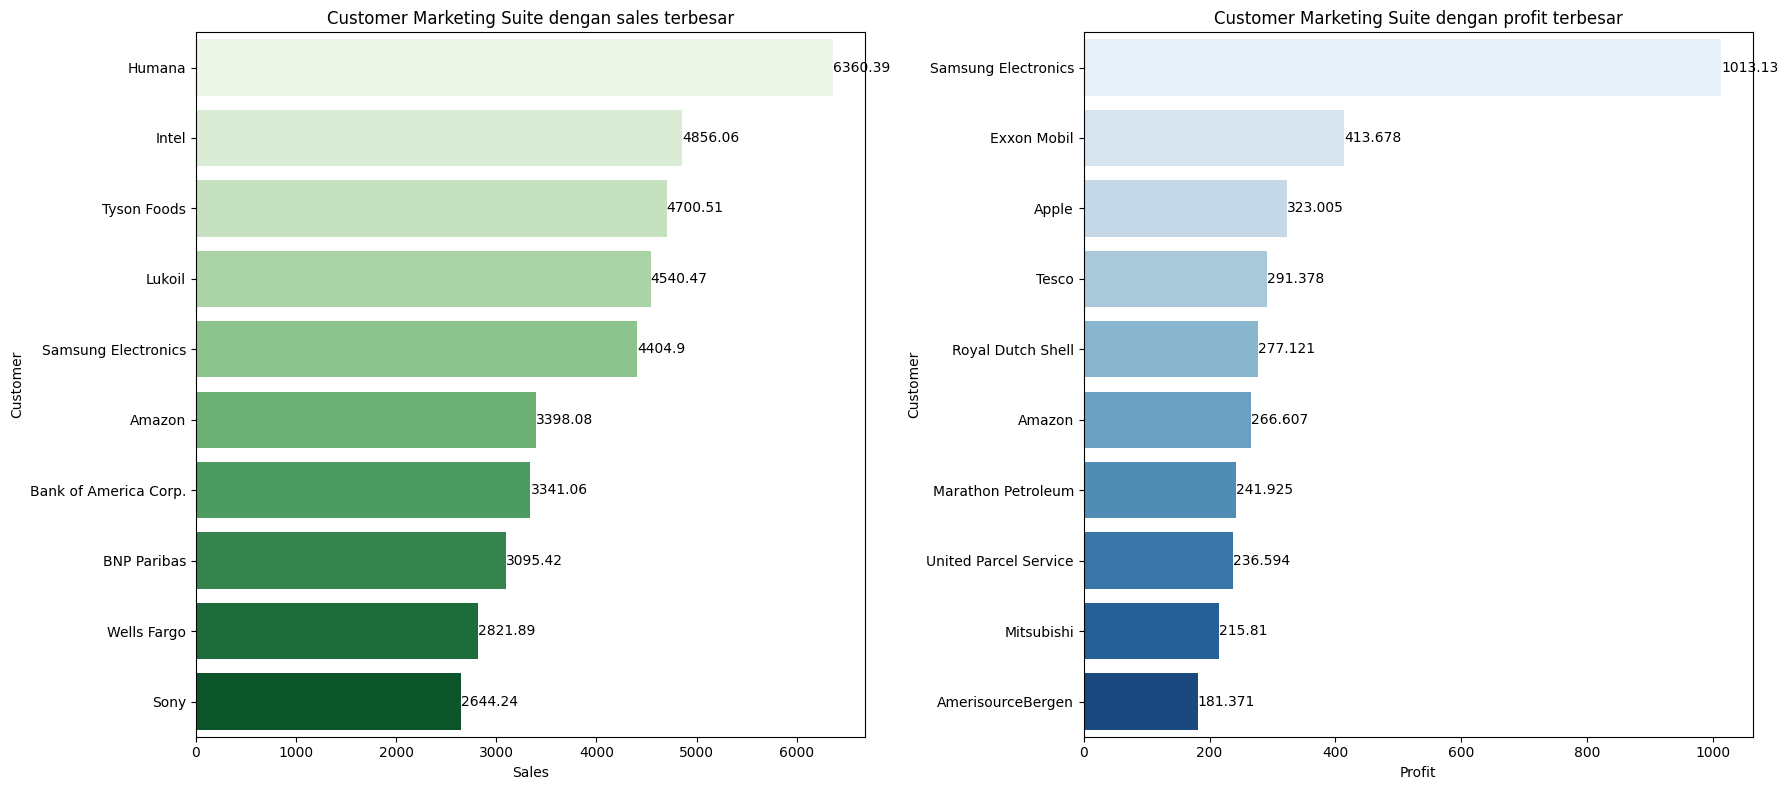

In [75]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(18,8))
sns.barplot(data=df_cust.sort_values(by='Sales',ascending=False).head(10),y='Customer',x='Sales',palette='Greens',ax=ax1)
sns.barplot(data=df_cust.sort_values(by='Profit',ascending=False).head(10),y='Customer',x='Profit',palette='Blues',ax=ax2)

ax1.set_title("Customer Marketing Suite dengan sales terbesar")
ax2.set_title("Customer Marketing Suite dengan profit terbesar")

for value in ax1.containers:
    ax1.bar_label(value)
    
for value in ax2.containers:
    ax2.bar_label(value)

plt.tight_layout()
plt.show()

C:\Users\dwisanjani\AppData\Local\Temp\ipykernel_34768\483472904.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_cust.sort_values(by='Profit Margin Percentage',ascending=False).head(10),y='Customer',x='Profit Margin Percentage',palette='Reds')


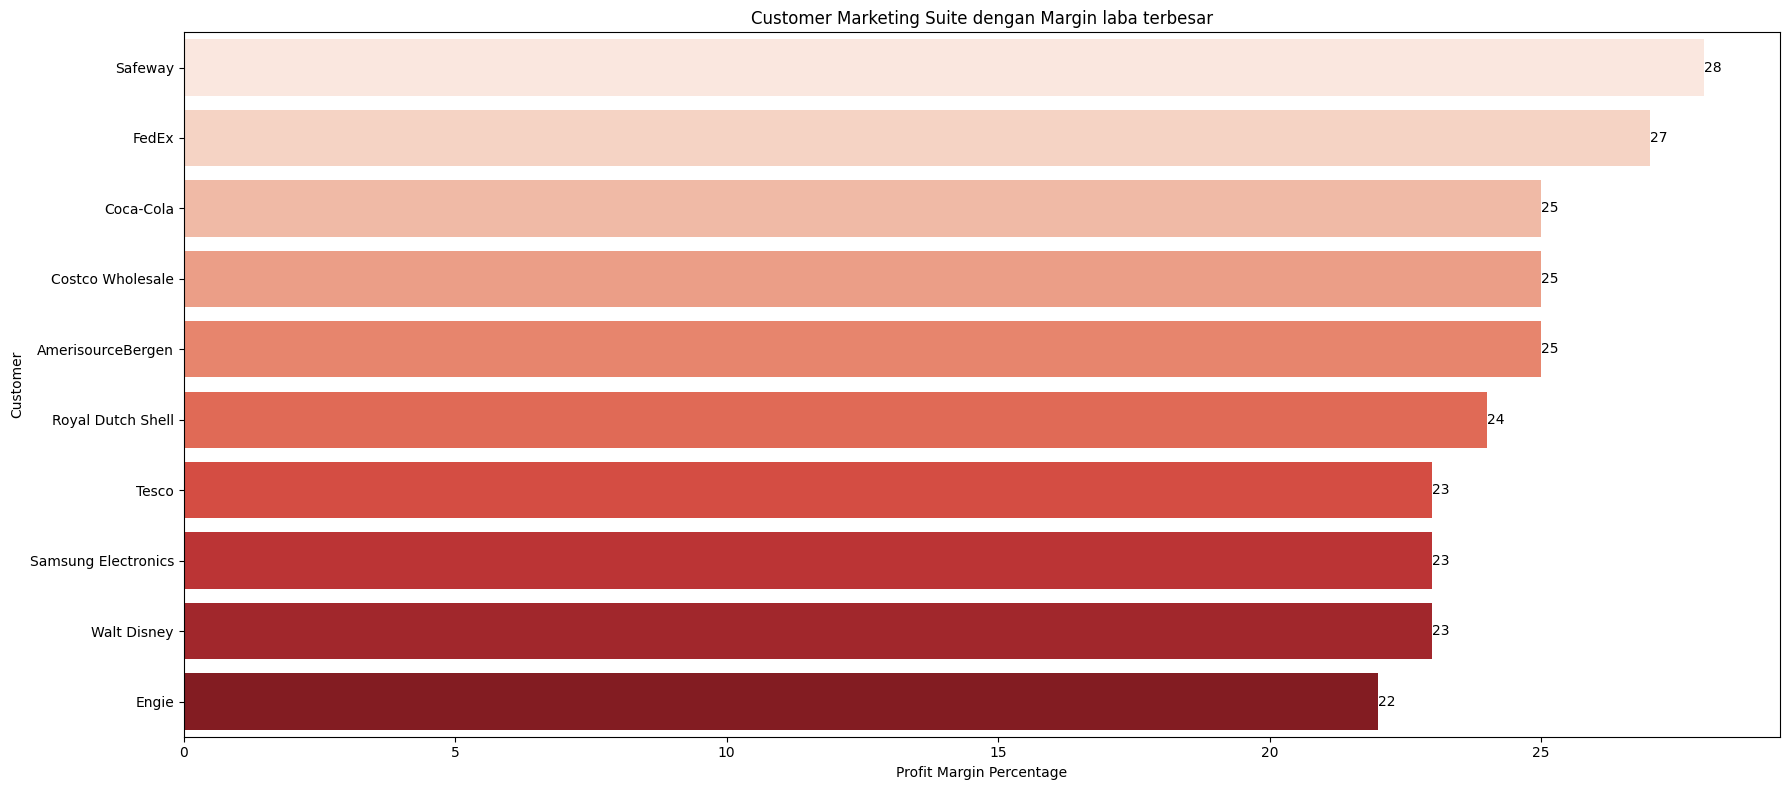

In [28]:
fig = plt.figure(figsize=(18,8))
ax = sns.barplot(data=df_cust.sort_values(by='Profit Margin Percentage',ascending=False).head(10),y='Customer',x='Profit Margin Percentage',palette='Reds')

for value in ax.containers:
    ax.bar_label(value)

plt.title("Customer Marketing Suite dengan Margin laba terbesar")

plt.tight_layout()
plt.show()

In [94]:
df_cust['Profitabillity'] = df_cust['Profit'].apply(lambda x:"Profit" if x>0 else "Loss")
df_cust_pie = df_cust.groupby('Profitabillity')['Customer'].nunique().reset_index()
df_cust_pie

,Profitabillity,Customer
0,Loss,44
1,Profit,45


In [98]:
df_cust[df_cust['Profitabillity']=='Loss']['Profit'].sum()

np.float64(-9646.464300000003)

Text(0.5, 1.0, 'Proporsi profit dan loss berdasarkan customer marketing suite')

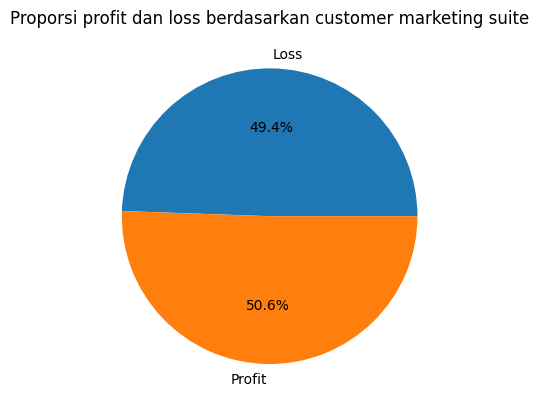

In [30]:
plt.pie(data=df_cust_pie,x='Customer',labels='Profitabillity',autopct='%1.1f%%')
plt.title("Proporsi profit dan loss berdasarkan customer marketing suite")

Text(0.5, 1.0, 'Proporsi segment customer marketing suite')

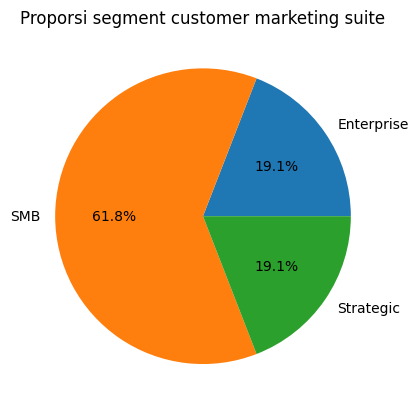

In [33]:
plt.pie(data=df_cust.groupby('Segment')['Customer'].nunique().reset_index(),x='Customer',labels='Segment',autopct='%1.1f%%')
plt.title("Proporsi segment customer marketing suite")

#### Penemuan
* Intel adalah customer marketing suite yang menyumbang kerugian terbesar, yaitu 1561.81
* Samsung Electronics adalah customer marketing suite yang menyumbang keuntungan terbesar, 1013.12
* Safeway merupakan customer marketing suite dengan margin laba terbesar, yaitu 28%
* 49.4% dari total customer marketing suite menyebabkan kerugian
* 61.8% Customer marketing suite datang dari segment SMB

#### Analisa
* Perlu dilakukan audit menyeluruh pada semua transaksi marketing suite dengan Intel
* Customer yang menyumbang profit terbesar hanya memiliki margin sebesar 23%, margin tersebut dinilai jauh dari kata sehat untuk produk SaaS
* margin laba dari semua penjualan marketing suite kepada customer terlalu rendah, perlu adanya pembenahan pada COGS seperti biaya marketing dan biaya yang terlibat langsung pada penentuan harga produk
* Strategi marketing marketing suite pada segmen SMB perlu diprioritaskan karena memiliki potensi yang jauh lebih besar dibandingkan segmen lainnya